# Phase 2: Traditional ML — TF-IDF + SVM / Logistic Regression / Naive Bayes

Baselines applied to ECHR judgment **FACTS sections only**.

**Primary scope:** Article 6 cases only (Article-6-specific label).
**Addon comparison:** All articles (952 cases, original `label` column — 58% violations vs 73% in Art.6).

Two evaluation settings:
- **Random split** (75/25 stratified)
- **Temporal split** (train on older cases, test on newer)

## 1. Setup

In [1]:
%matplotlib inline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

for pkg_path, pkg_name in [
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet',   'wordnet'),
    ('corpora/omw-1.4',  'omw-1.4'),
]:
    try:
        nltk.data.find(pkg_path)
    except LookupError:
        nltk.download(pkg_name)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Legal Tokenizer

Ported from the EDA notebook's shared lexical preprocessing pipeline for consistency across phases.
Note: `has_representation` was excluded as a feature — EDA found it is not a strong correlate of outcome in FACTS-only text.

In [2]:
wnl = WordNetLemmatizer()

LEGAL_EXTRA_STOPWORDS = {"mr", "mrs", "ms", "court", "case"}
ALL_STOPWORDS = set(nltk_stopwords.words("english")) | LEGAL_EXTRA_STOPWORDS

MANUAL_LEMMA_MAP = {
    "applicants": "applicant", "authorities": "authority",
    "proceedings": "proceeding", "judges": "judge",
    "lawyers": "lawyer", "officers": "officer",
    "children": "child", "women": "woman", "men": "man",
}

def normalize_token(tok):
    tok = tok.lower().strip()
    tok = MANUAL_LEMMA_MAP.get(tok, tok)
    if not re.search(r"[a-z]", tok):
        return ""
    return wnl.lemmatize(tok, pos="n")

def legal_tokenizer(text):
    tokens = re.findall(r"[a-z']+", str(text).lower())
    return [t for tok in tokens
            if (t := normalize_token(tok)) and len(t) > 2 and t not in ALL_STOPWORDS]

print(legal_tokenizer("The applicants' lawyers filed proceedings before the authorities."))

["applicants'", 'lawyer', 'filed', 'proceeding', 'authority']


## 3. Load & Filter Data

In [3]:
df_all = pd.read_csv('data/processed/processed.csv')

def contains_article(series, article='6'):
    return series.astype(str).str.split(';').apply(lambda arts: article in arts)

# --- Article 6 subset ---
art6_v  = contains_article(df_all['violation_articles'],    '6')
art6_nv = contains_article(df_all['nonviolation_articles'], '6')
df6 = df_all[art6_v | art6_nv].copy()
df6['label_art6'] = art6_v[df6.index].astype(int)

# --- All articles ---
df_full = df_all.copy()

print(f'Article 6 subset : {len(df6)} cases | violation rate: {df6["label_art6"].mean():.2%}')
print(f'All articles      : {len(df_full)} cases | violation rate: {df_full["label"].mean():.2%}')

Article 6 subset : 436 cases | violation rate: 73.39%
All articles      : 952 cases | violation rate: 57.88%


## 4. TF-IDF & Pipeline Helpers

In [4]:
def make_tfidf():
    return TfidfVectorizer(
        tokenizer=legal_tokenizer, preprocessor=None, token_pattern=None,
        lowercase=False, min_df=3, max_df=0.90, sublinear_tf=True, ngram_range=(1, 2),
    )

def eval_report(name, y_true, y_pred):
    """Return a one-row dict of metrics for the comparison table."""
    return {
        'Model':             name,
        'Accuracy':          round(accuracy_score(y_true, y_pred), 3),
        'Macro-F1':          round(f1_score(y_true, y_pred, average='macro'), 3),
        'F1 (Violation)':    round(f1_score(y_true, y_pred, pos_label=1, average='binary'), 3),
        'F1 (No Violation)': round(f1_score(y_true, y_pred, pos_label=0, average='binary'), 3),
    }

# Vocabulary size on Art6 corpus
X6 = df6['text'].values
y6 = df6['label_art6'].values
print(f'Art6 vocabulary : {len(make_tfidf().fit(X6).vocabulary_):,} n-grams')
print(f'Full vocabulary : {len(make_tfidf().fit(df_full["text"].values).vocabulary_):,} n-grams')

Art6 vocabulary : 16,681 n-grams
Full vocabulary : 46,500 n-grams


## 5. Hyperparameter Search (Article 6)

Grid search over `C` and `class_weight` for LinearSVC.
`class_weight='balanced'` reweights loss by inverse class frequency — directly addresses the 73% / 27% imbalance.

In [5]:
X_train6, X_test6, y_train6, y_test6 = train_test_split(
    X6, y6, test_size=0.25, stratify=y6, random_state=RANDOM_STATE
)
print(f'Art6 — Train: {len(X_train6)} | Test: {len(X_test6)}')

param_grid = {
    'svm__C':            [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'svm__class_weight': [None, 'balanced'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs = GridSearchCV(
    Pipeline([('tfidf', make_tfidf()), ('svm', LinearSVC(max_iter=2000, random_state=RANDOM_STATE))]),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs.fit(X_train6, y_train6)

BEST_C  = gs.best_params_['svm__C']
BEST_CW = gs.best_params_['svm__class_weight']
print(f'\nBest C={BEST_C}, class_weight={BEST_CW} | CV macro-F1: {gs.best_score_:.3f}')

Art6 — Train: 327 | Test: 109

Best C=0.1, class_weight=balanced | CV macro-F1: 0.678


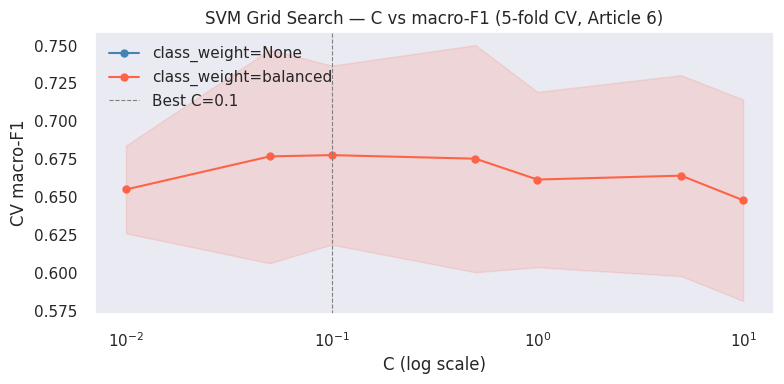

In [6]:
results_gs = pd.DataFrame(gs.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4))

for cw, color, label in [(None, 'steelblue', 'class_weight=None'), ('balanced', 'tomato', 'class_weight=balanced')]:
    mask = results_gs['param_svm__class_weight'] == cw
    sub  = results_gs[mask].sort_values('param_svm__C')
    ax.plot(sub['param_svm__C'], sub['mean_test_score'], marker='o', color=color, label=label)
    ax.fill_between(sub['param_svm__C'],
                    sub['mean_test_score'] - sub['std_test_score'],
                    sub['mean_test_score'] + sub['std_test_score'],
                    alpha=0.15, color=color)

ax.axvline(BEST_C, linestyle='--', color='gray', linewidth=0.8, label=f'Best C={BEST_C}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV macro-F1')
ax.set_title('SVM Grid Search — C vs macro-F1 (5-fold CV, Article 6)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation — Article 6, Random Split (75/25)

In [7]:
models_art6 = {
    'Dummy (majority)': Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  DummyClassifier(strategy='most_frequent'))]),
    'Naive Bayes':      Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  ComplementNB())]),
    'SVM':              Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  LinearSVC(C=BEST_C, class_weight=BEST_CW,
                                                      max_iter=2000, random_state=RANDOM_STATE))]),
    'Logistic Reg':     Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  LogisticRegression(C=BEST_C, class_weight=BEST_CW,
                                                               max_iter=1000, random_state=RANDOM_STATE))]),
}

preds_art6_r = {}
for name, pipe in models_art6.items():
    pipe.fit(X_train6, y_train6)
    preds_art6_r[name] = pipe.predict(X_test6)
    print(f'--- {name} ---')
    print(classification_report(y_test6, preds_art6_r[name], target_names=['No Violation', 'Violation']))

--- Dummy (majority) ---
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        29
   Violation       0.73      1.00      0.85        80

    accuracy                           0.73       109
   macro avg       0.37      0.50      0.42       109
weighted avg       0.54      0.73      0.62       109

--- Naive Bayes ---
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        29
   Violation       0.73      1.00      0.85        80

    accuracy                           0.73       109
   macro avg       0.37      0.50      0.42       109
weighted avg       0.54      0.73      0.62       109

--- SVM ---
              precision    recall  f1-score   support

No Violation       0.57      0.69      0.62        29
   Violation       0.88      0.81      0.84        80

    accuracy                           0.78       109
   macro avg       0.72      0.75      0.73       109
weighted avg     

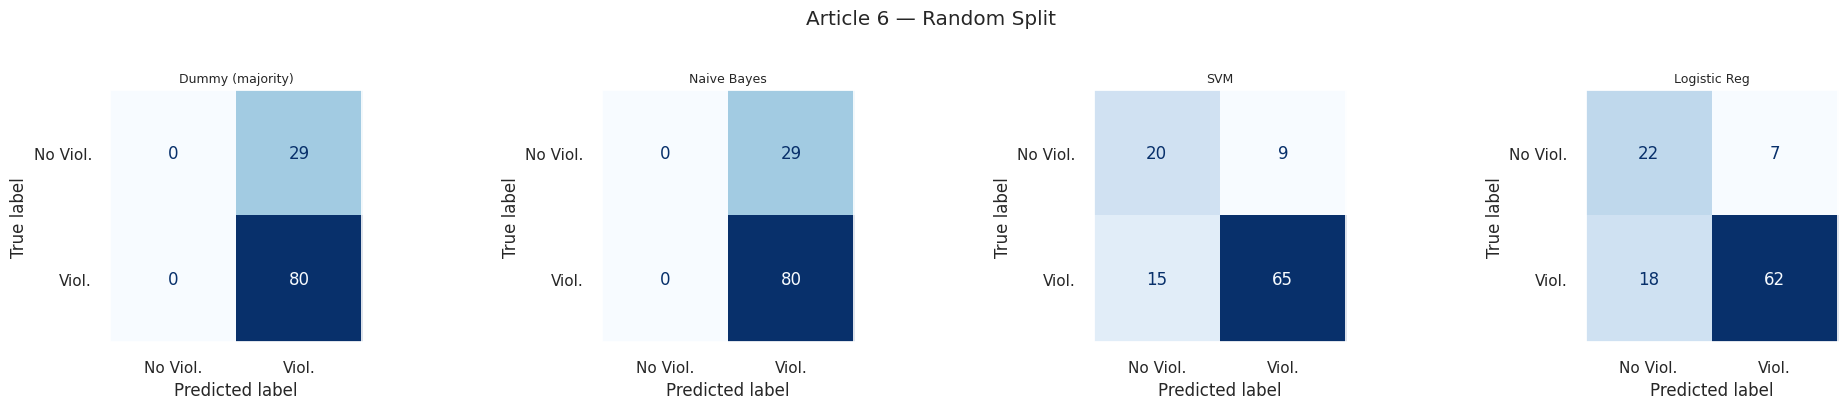

In [8]:
fig, axes = plt.subplots(1, len(models_art6), figsize=(5 * len(models_art6), 4))
for ax, (name, y_pred) in zip(axes, preds_art6_r.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test6, y_pred),
                           display_labels=['No Viol.', 'Viol.']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
plt.suptitle('Article 6 — Random Split', y=1.02)
plt.tight_layout()
plt.show()

## 7. Evaluation — Article 6, Temporal Split

In [9]:
split_year = int(np.percentile(df6['year'].dropna(), 75))
train_m = df6['year'] < split_year
test_m  = df6['year'] >= split_year
X_train6t = df6.loc[train_m, 'text'].values;  y_train6t = df6.loc[train_m, 'label_art6'].values
X_test6t  = df6.loc[test_m,  'text'].values;  y_test6t  = df6.loc[test_m,  'label_art6'].values
print(f'Temporal split year: {split_year} | Train: {len(X_train6t)} | Test: {len(X_test6t)}')

preds_art6_t = {}
for name, pipe in models_art6.items():
    # Re-fit on temporal train split (each pipe already has best params)
    import copy
    p = copy.deepcopy(pipe)
    p.fit(X_train6t, y_train6t)
    preds_art6_t[name] = p.predict(X_test6t)
    print(f'--- {name} ---')
    print(classification_report(y_test6t, preds_art6_t[name], target_names=['No Violation', 'Violation']))

Temporal split year: 2012 | Train: 278 | Test: 158
--- Dummy (majority) ---
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        52
   Violation       0.67      1.00      0.80       106

    accuracy                           0.67       158
   macro avg       0.34      0.50      0.40       158
weighted avg       0.45      0.67      0.54       158

--- Naive Bayes ---
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        52
   Violation       0.67      1.00      0.80       106

    accuracy                           0.67       158
   macro avg       0.34      0.50      0.40       158
weighted avg       0.45      0.67      0.54       158

--- SVM ---
              precision    recall  f1-score   support

No Violation       0.50      0.38      0.43        52
   Violation       0.73      0.81      0.77       106

    accuracy                           0.67       158
   macro avg       0

## 8. Model Comparison — Article 6

In [10]:
rows = []
for name in models_art6:
    r = eval_report(name, y_test6,  preds_art6_r[name])
    r['Split'] = 'Random';   rows.append(r)
    r = eval_report(name, y_test6t, preds_art6_t[name])
    r['Split'] = 'Temporal'; rows.append(r)

comp6 = pd.DataFrame(rows).set_index(['Model', 'Split'])
display(comp6)

Accuracy  Macro-F1  F1 (Violation)  \
Model            Split                                          
Dummy (majority) Random       0.734     0.423           0.847   
                 Temporal     0.671     0.402           0.803   
Naive Bayes      Random       0.734     0.423           0.847   
                 Temporal     0.671     0.402           0.803   
SVM              Random       0.780     0.735           0.844   
                 Temporal     0.671     0.601           0.768   
Logistic Reg     Random       0.771     0.735           0.832   
                 Temporal     0.658     0.586           0.759   

                           F1 (No Violation)  
Model            Split                        
Dummy (majority) Random                0.000  
                 Temporal              0.000  
Naive Bayes      Random                0.000  
                 Temporal              0.000  
SVM              Random                0.625  
                 Temporal              0.435  
Logistic Reg     Random                0.638  
                 Temporal              0.413

## 9. Addon — All Articles Comparison

Using all 952 cases with the original binary `label` (58% violations vs 73% in Art.6).
More training data and better class balance — shows whether Art.6 scoping is a limiting factor.

In [11]:
X_full = df_full['text'].values
y_full = df_full['label'].values

X_trainF, X_testF, y_trainF, y_testF = train_test_split(
    X_full, y_full, test_size=0.25, stratify=y_full, random_state=RANDOM_STATE
)
print(f'All articles — Train: {len(X_trainF)} | Test: {len(X_testF)}')
print(f'Test violation rate: {y_testF.mean():.2%}')

# Temporal split for all articles
split_year_full = int(np.percentile(df_full['year'].dropna(), 75))
train_mF = df_full['year'] < split_year_full
test_mF  = df_full['year'] >= split_year_full
X_trainFt = df_full.loc[train_mF, 'text'].values;  y_trainFt = df_full.loc[train_mF, 'label'].values
X_testFt  = df_full.loc[test_mF,  'text'].values;  y_testFt  = df_full.loc[test_mF,  'label'].values
print(f'Temporal split year: {split_year_full} | Train: {len(X_trainFt)} | Test: {len(X_testFt)}')

All articles — Train: 714 | Test: 238
Test violation rate: 57.98%
Temporal split year: 2013 | Train: 686 | Test: 266


In [12]:
models_full = {
    'Dummy (majority)': Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  DummyClassifier(strategy='most_frequent'))]),
    'Naive Bayes':      Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  ComplementNB())]),
    'SVM':              Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  LinearSVC(C=BEST_C, class_weight=BEST_CW,
                                                      max_iter=2000, random_state=RANDOM_STATE))]),
    'Logistic Reg':     Pipeline([('tfidf', make_tfidf()),
                                   ('clf',  LogisticRegression(C=BEST_C, class_weight=BEST_CW,
                                                               max_iter=1000, random_state=RANDOM_STATE))]),
}

preds_full_r = {}
preds_full_t = {}

for name, pipe in models_full.items():
    pipe.fit(X_trainF, y_trainF)
    preds_full_r[name] = pipe.predict(X_testF)

    import copy
    p = copy.deepcopy(pipe)
    p.fit(X_trainFt, y_trainFt)
    preds_full_t[name] = p.predict(X_testFt)

rows_full = []
for name in models_full:
    r = eval_report(name, y_testF,  preds_full_r[name])
    r['Split'] = 'Random';   rows_full.append(r)
    r = eval_report(name, y_testFt, preds_full_t[name])
    r['Split'] = 'Temporal'; rows_full.append(r)

comp_full = pd.DataFrame(rows_full).set_index(['Model', 'Split'])
display(comp_full)

Accuracy  Macro-F1  F1 (Violation)  \
Model            Split                                          
Dummy (majority) Random       0.580     0.367           0.734   
                 Temporal     0.173     0.147           0.295   
Naive Bayes      Random       0.676     0.598           0.776   
                 Temporal     0.173     0.147           0.295   
SVM              Random       0.710     0.697           0.760   
                 Temporal     0.282     0.282           0.268   
Logistic Reg     Random       0.714     0.705           0.757   
                 Temporal     0.301     0.300           0.279   

                           F1 (No Violation)  
Model            Split                        
Dummy (majority) Random                0.000  
                 Temporal              0.000  
Naive Bayes      Random                0.421  
                 Temporal              0.000  
SVM              Random                0.635  
                 Temporal              0.295  
Logistic Reg     Random                0.653  
                 Temporal              0.321

## 10. Side-by-Side: Article 6 vs All Articles

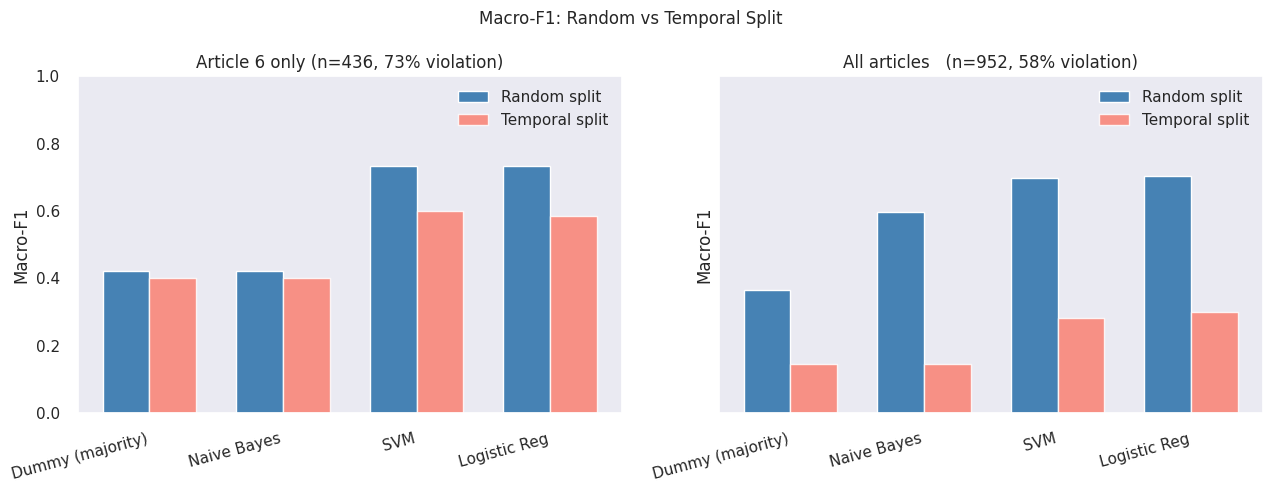

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, comp, title in [
    (axes[0], comp6,     'Article 6 only (n=436, 73% violation)'),
    (axes[1], comp_full, 'All articles   (n=952, 58% violation)'),
]:
    random_rows = comp.xs('Random', level='Split')
    x = np.arange(len(random_rows))
    width = 0.35
    ax.bar(x - width/2, random_rows['Macro-F1'],
           width, label='Random split', color='steelblue')

    temporal_rows = comp.xs('Temporal', level='Split')
    ax.bar(x + width/2, temporal_rows['Macro-F1'],
           width, label='Temporal split', color='salmon', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(random_rows.index, rotation=15, ha='right')
    ax.set_ylabel('Macro-F1')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Macro-F1: Random vs Temporal Split', fontsize=12)
plt.tight_layout()
plt.show()

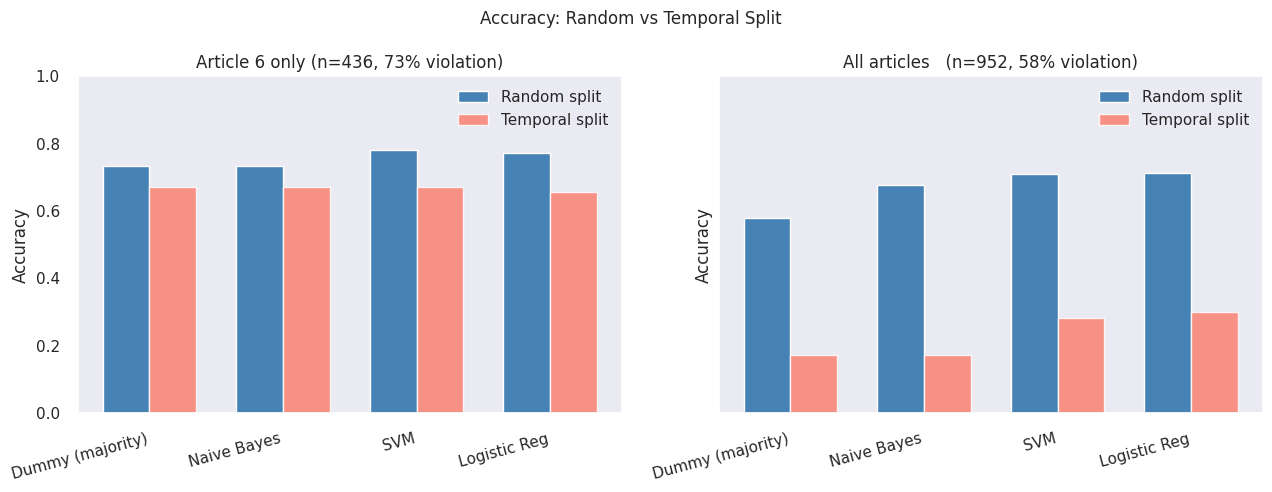

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, comp, title in [
    (axes[0], comp6,     'Article 6 only (n=436, 73% violation)'),
    (axes[1], comp_full, 'All articles   (n=952, 58% violation)'),
]:
    random_rows = comp.xs('Random', level='Split')
    x = np.arange(len(random_rows))
    width = 0.35
    ax.bar(x - width/2, random_rows['Accuracy'],
           width, label='Random split', color='steelblue')

    temporal_rows = comp.xs('Temporal', level='Split')
    ax.bar(x + width/2, temporal_rows['Accuracy'],
           width, label='Temporal split', color='salmon', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(random_rows.index, rotation=15, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Accuracy: Random vs Temporal Split', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Bias Analysis — Per-Country (Article 6, Random Split)

In [14]:
_, test_idx6 = train_test_split(np.arange(len(df6)), test_size=0.25, stratify=y6, random_state=RANDOM_STATE)
test_df6 = df6.iloc[test_idx6].copy()
for name, y_pred in preds_art6_r.items():
    test_df6[f'pred_{name}'] = y_pred

country_rows = []
for country, grp in test_df6.groupby('respondent'):
    row = {'Country': country, 'n': len(grp), 'Violation rate': grp['label_art6'].mean()}
    for name in models_art6:
        row[name] = (grp[f'pred_{name}'] == grp['label_art6']).mean()
    country_rows.append(row)

country_stats = pd.DataFrame(country_rows).set_index('Country').round(3)
display(country_stats)

,n,Violation rate,Dummy (majority),Naive Bayes,SVM,Logistic Reg
Country,,,,,,
GBR,44,0.659,0.659,0.659,0.705,0.636
RUS,38,0.763,0.763,0.763,0.763,0.789
TUR,27,0.815,0.815,0.815,0.926,0.963


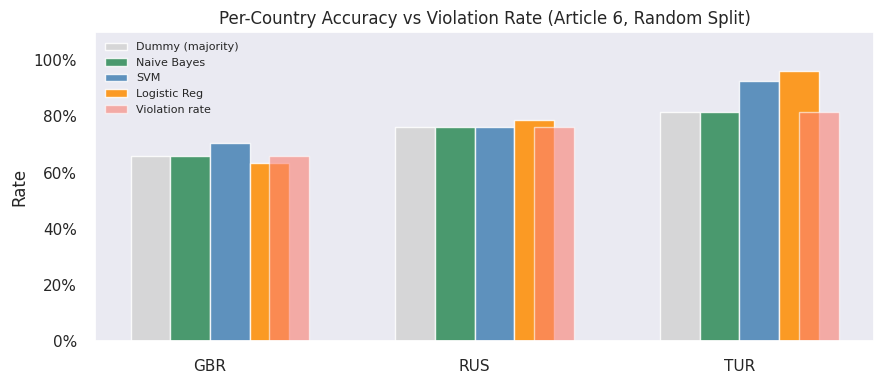

In [15]:
model_names = list(models_art6.keys())
countries   = country_stats.index.tolist()
x = np.arange(len(countries))
colors = ['lightgray', 'seagreen', 'steelblue', 'darkorange']
width  = 0.15

fig, ax = plt.subplots(figsize=(9, 4))
for i, (name, color) in enumerate(zip(model_names, colors)):
    ax.bar(x + (i - 1.5) * width, country_stats[name], width, label=name, color=color, alpha=0.85)

ax.bar(x + 2 * width, country_stats['Violation rate'], width,
       label='Violation rate', color='salmon', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Per-Country Accuracy vs Violation Rate (Article 6, Random Split)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12. Top Discriminating Features (SVM, Article 6)

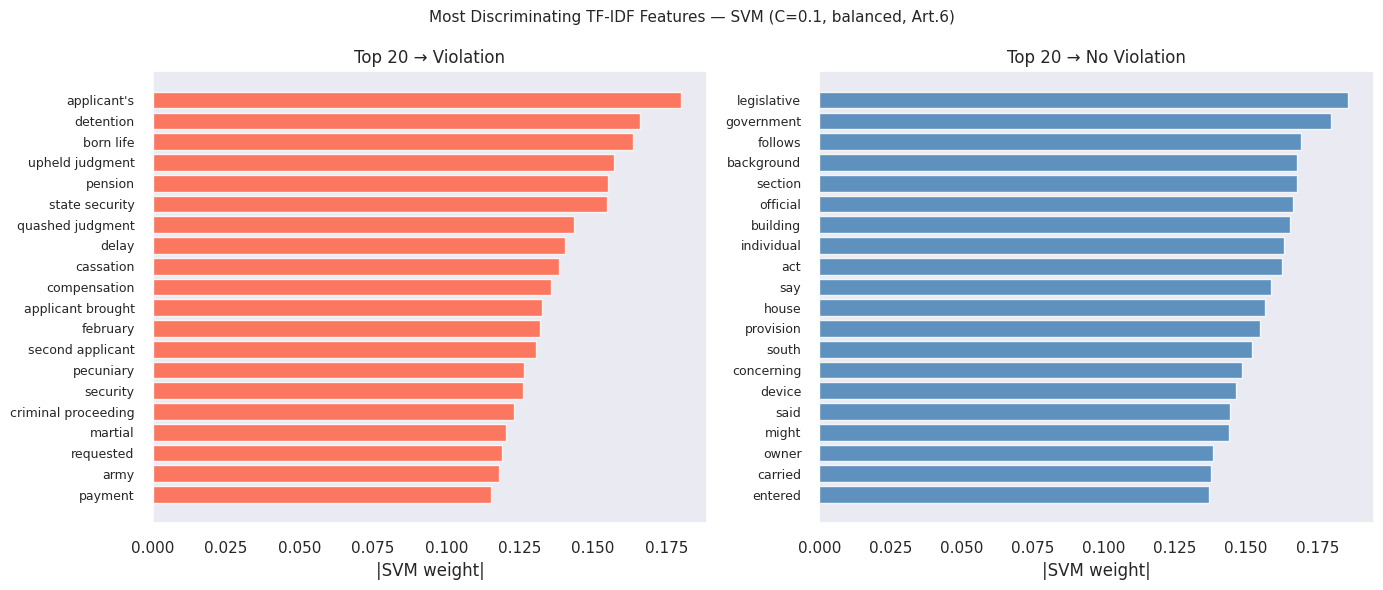

In [16]:
svm_pipe      = models_art6['SVM']
feature_names = np.array(svm_pipe.named_steps['tfidf'].get_feature_names_out())
coef          = svm_pipe.named_steps['clf'].coef_[0]

N = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title, color in [
    (axes[0], np.argsort(coef)[-N:][::-1], f'Top {N} → Violation',    'tomato'),
    (axes[1], np.argsort(coef)[:N],        f'Top {N} → No Violation', 'steelblue'),
]:
    terms  = feature_names[idx]
    values = np.abs(coef[idx])
    ax.barh(range(N), values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(N))
    ax.set_yticklabels(terms[::-1], fontsize=9)
    ax.set_xlabel('|SVM weight|')
    ax.set_title(title)

plt.suptitle(f'Most Discriminating TF-IDF Features — SVM (C={BEST_C}, {BEST_CW}, Art.6)', fontsize=11)
plt.tight_layout()
plt.show()

## 13. Summary

**Interpretation guide:**
- **Dummy baseline** sets the floor: any model not clearly above it on macro-F1 is not learning beyond class frequency.
- **Accuracy ≈ violation rate** per country (especially for NB) confirms the model exploits base rates, not legal content.
- **Random → Temporal drop** in macro-F1 is the primary evidence of temporal spurious correlation.
- **Art.6 vs All-articles** shows whether corpus size and class balance are limiting factors.